In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import random_split, DataLoader
from torch.optim.lr_scheduler import StepLR, SequentialLR, LambdaLR, OneCycleLR
import os
import matplotlib.pyplot as plt
import numpy as np
import copy
from sklearn.manifold import TSNE
import umap.umap_ as umap

/home/alvinng44/.local/share/mamba/envs/alyssa/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-29 02:33:10.797003: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 02:33:10.861055: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 02:33:12.328805: I tensorflow/core/util/port.cc:153] oneDNN custom ope

In [11]:
data_transforms = {
    "train" : transforms.Compose([
        transforms.Resize(size = (224, 224)), # resize to 224 by 224 for resnet
        # transforms.CenterCrop(size = (224, 224)),
        # transforms.Grayscale(num_output_channels = 3), # this converts grayscale to rgb channels
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
    ]),
    "test" : transforms.Compose([
        transforms.Resize(size = (224, 224)), # resize to 224 by 224 for resnet
        # transforms.CenterCrop(size = (224, 224)),
        # transforms.Grayscale(num_output_channels = 3), # this converts grayscale to rgb channels
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
    ])
}

In [12]:
train_ds = datasets.ImageFolder(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/SAMPLE/png_images/decibel/synth",
    transform = data_transforms["train"]
)

test_ds = datasets.ImageFolder(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/SAMPLE/png_images/decibel/real",
    transform = data_transforms["test"]
)

ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

dataloaders = {x : DataLoader(ds_dict[x], batch_size = 32, num_workers = 4, shuffle = True) for x in ds_dict.keys()}

In [13]:
# load pre-trained model
model = models.resnet18(weights = "DEFAULT")
# Replace final layer for the number of classes
model.fc = nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))

# Freeze all layers except final layer
# final layer is responsible for classification
for name, param in model.named_parameters():
    if "fc" in name:
        # unfreeze the fc layers
        # this means we are only training the fc layers
        param.requires_grad = True 
    else:
        param.requires_grad = False

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss() # most common used nn for classification problems

optimizer = optim.SGD(model.parameters(), lr = 0.01)

scheduler = OneCycleLR(optimizer, max_lr = 0.00125, epochs = 100, steps_per_epoch = len(dataloaders["train"]))

# move model to GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [14]:
history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

# Training loops
num_epochs = 100
for epoch in range(num_epochs):
    print(f"Epoch {epoch}")
    for phase in ["train", "test"]:
        if phase == "train":
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0 # correct predictions

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() # clear the gradient from previous iteration

            with torch.set_grad_enabled(phase == "train"):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels) # check if output and labels match

                if phase == "train":
                    loss.backward()
                    optimizer.step()
                    scheduler.step() # scheduler here if OneCycleLR

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        
        history[f"{phase}_loss"].append(epoch_loss)
        history[f"{phase}_acc"].append(epoch_acc.item())

        print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

    # scheduler.step()
    print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

print("Training complete!")

Epoch 0
train Loss: 2.3627 Acc: 0.1361
test Loss: 2.4245 Acc: 0.0751
Epoch 0 LR: 0.0000532920
Epoch 1
train Loss: 2.2731 Acc: 0.1621
test Loss: 2.3195 Acc: 0.1197
Epoch 1 LR: 0.0000631317
Epoch 2
train Loss: 2.2337 Acc: 0.1770
test Loss: 2.3077 Acc: 0.1368
Epoch 2 LR: 0.0000794113
Epoch 3
train Loss: 2.1932 Acc: 0.2007
test Loss: 2.3151 Acc: 0.1242
Epoch 3 LR: 0.0001019521
Epoch 4
train Loss: 2.1476 Acc: 0.2164
test Loss: 2.3015 Acc: 0.1457
Epoch 4 LR: 0.0001305067
Epoch 5
train Loss: 2.0924 Acc: 0.2587
test Loss: 2.3196 Acc: 0.1554
Epoch 5 LR: 0.0001647618
Epoch 6
train Loss: 2.0340 Acc: 0.2788
test Loss: 2.3641 Acc: 0.1145
Epoch 6 LR: 0.0002043415
Epoch 7
train Loss: 1.9714 Acc: 0.3279
test Loss: 2.3687 Acc: 0.1271
Epoch 7 LR: 0.0002488115
Epoch 8
train Loss: 1.9206 Acc: 0.3398
test Loss: 2.3775 Acc: 0.1123
Epoch 8 LR: 0.0002976839
Epoch 9
train Loss: 1.8542 Acc: 0.3747
test Loss: 2.4416 Acc: 0.1428
Epoch 9 LR: 0.0003504222
Epoch 10
train Loss: 1.7933 Acc: 0.4007
test Loss: 2.4425 Ac

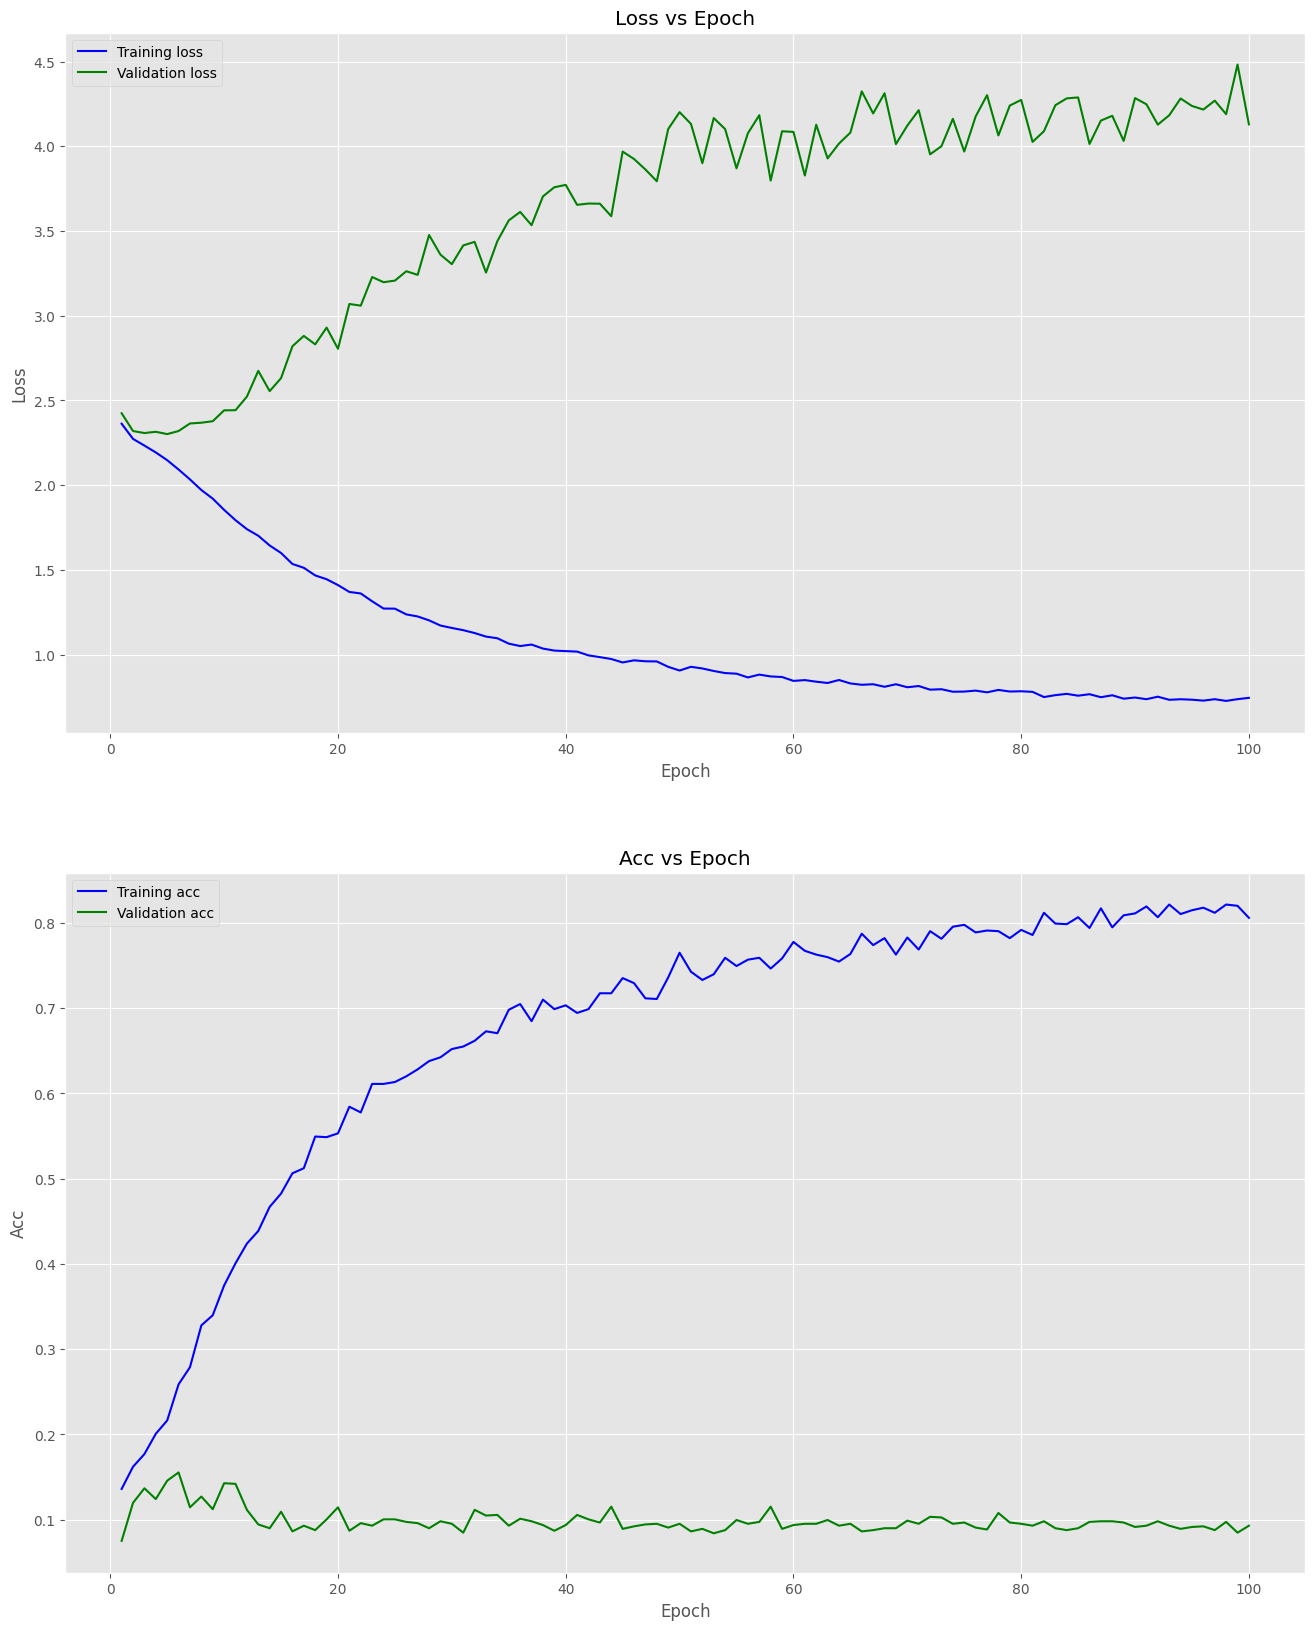

In [15]:
with plt.style.context("ggplot"):
    fig = plt.figure(figsize = (16, 20))

    ax0 = fig.add_subplot(2, 1, 1)
    ax0.plot(np.arange(1, num_epochs+1), history["train_loss"], label = "Training loss", c = "blue")
    ax0.plot(np.arange(1, num_epochs+1), history["test_loss"], label = "Validation loss", c = "green")
    ax0.set_title("Loss vs Epoch")
    ax0.set_xlabel("Epoch")
    ax0.set_ylabel("Loss")
    ax0.legend()
    ax0.grid(True)
    
    ax1 = fig.add_subplot(2, 1, 2)
    ax1.plot(np.arange(1, num_epochs+1), history["train_acc"], label = "Training acc", c = "blue")
    ax1.plot(np.arange(1, num_epochs+1), history["test_acc"], label = "Validation acc", c = "green")
    ax1.set_title("Acc vs Epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Acc")
    ax1.legend()
    ax1.grid(True)

    plt.show()